In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

In [79]:
# Load data
df = pd.read_csv("/content/data.csv")

In [80]:

# Features and target
X = df.iloc[:, 2:32].values
y = df.iloc[:, 1].map({'M': 1, 'B': 0}).values

In [81]:
# 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [82]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
# Distance functions
def distance(a, b, method):
    if method == "Euclidean":
        return np.sqrt(np.sum((a-b)**2))
    if method == "Manhattan":
        return np.sum(np.abs(a-b))
    if method == "Minkowski":
        return np.sum(np.abs(a-b)**3)**(1/3)
    if method == "Cosine":
        return 1 - np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
    if method == "Hamming":
        return np.mean(a != b)

In [84]:
# KNN from scratch
def knn(Xtr, ytr, Xte, k, method):
    pred = []

    for x in Xte:
        d = [(distance(x, xtr, method), label)
             for xtr, label in zip(Xtr, ytr)]

        d.sort()
        labels = [label for _, label in d[:k]]
        pred.append(max(set(labels), key=labels.count))

    return np.array(pred)


In [85]:
# Experiment
Ks = [3, 4, 9, 20, 47]
methods = ["Euclidean", "Manhattan", "Minkowski", "Cosine", "Hamming"]

results = {}

for method in methods:
    results[method] = []

    for k in Ks:
        y_pred = knn(X_train, y_train, X_test, k, method)
        acc = accuracy_score(y_test, y_pred)
        results[method].append(acc)

        print(method, "K =", k, "Accuracy =", round(acc, 4))

Euclidean K = 3 Accuracy = 0.9386
Euclidean K = 4 Accuracy = 0.9386
Euclidean K = 9 Accuracy = 0.9474
Euclidean K = 20 Accuracy = 0.9386
Euclidean K = 47 Accuracy = 0.9474
Manhattan K = 3 Accuracy = 0.9649
Manhattan K = 4 Accuracy = 0.9561
Manhattan K = 9 Accuracy = 0.9561
Manhattan K = 20 Accuracy = 0.9474
Manhattan K = 47 Accuracy = 0.9386
Minkowski K = 3 Accuracy = 0.9386
Minkowski K = 4 Accuracy = 0.9123
Minkowski K = 9 Accuracy = 0.9474
Minkowski K = 20 Accuracy = 0.9386
Minkowski K = 47 Accuracy = 0.9474
Cosine K = 3 Accuracy = 0.9474
Cosine K = 4 Accuracy = 0.9386
Cosine K = 9 Accuracy = 0.9561
Cosine K = 20 Accuracy = 0.9474
Cosine K = 47 Accuracy = 0.9474
Hamming K = 3 Accuracy = 0.7018
Hamming K = 4 Accuracy = 0.6842
Hamming K = 9 Accuracy = 0.6667
Hamming K = 20 Accuracy = 0.6316
Hamming K = 47 Accuracy = 0.6316


In [86]:
# Best model
best_method, best_accs = max(
    results.items(), key=lambda x: max(x[1])
)

best_k = Ks[np.argmax(best_accs)]
best_acc = max(best_accs)

print("\nBest K =", best_k)
print("Best Distance =", best_method)
print("Best Accuracy =", round(best_acc, 4))


Best K = 3
Best Distance = Manhattan
Best Accuracy = 0.9649


In [87]:
# Best model metrics
y_pred = knn(X_train, y_train, X_test, best_k, best_method)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))


Confusion Matrix:
 [[72  0]
 [ 4 38]]
Precision: 1.0
Recall: 0.9048


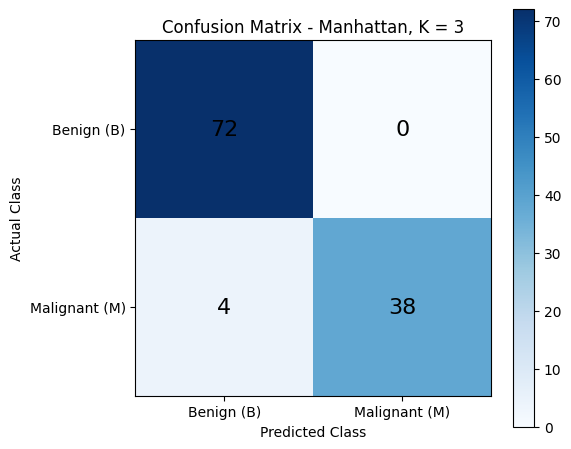

In [88]:
# Plot Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap='Blues')

plt.title(f"Confusion Matrix - {best_method}, K = {best_k}")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ['Benign (B)', 'Malignant (M)'])
plt.yticks([0, 1], ['Benign (B)', 'Malignant (M)'])

# Display values
for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=16
        )

plt.colorbar()

plt.tight_layout()
plt.show()

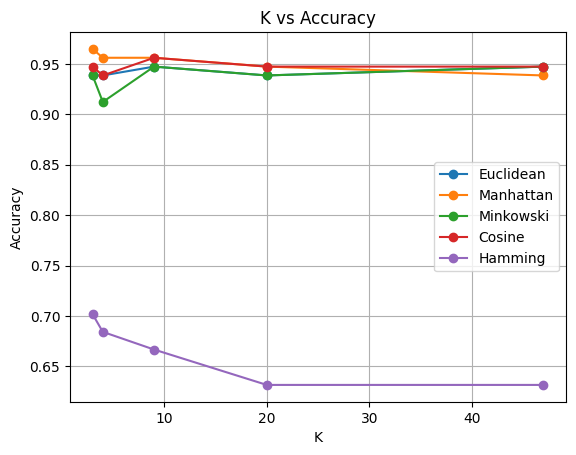

In [89]:
# K vs Accuracy plot
for method in methods:
    plt.plot(Ks, results[method], marker='o', label=method)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.legend()
plt.grid()
plt.show()






In [90]:
 #BONUS: DECISION BOUNDARY FOR BEST KNN MODEL
 # Select two features
X_train_2D = X_train[:, [0, 1]]

In [91]:
# KNN prediction for 2D points
def knn_2d(Xtr, ytr, Xte, k, method):
    predictions = []

    for x in Xte:

        d = []

        for xtr, label in zip(Xtr, ytr):

            dist = distance(x, xtr, method)

            d.append((dist, label))

        d.sort(key=lambda x: x[0])

        labels = [
            label for _, label in d[:k]
        ]

        predictions.append(
            max(set(labels), key=labels.count)
        )

    return np.array(predictions)

In [92]:
# Create grid
x_min = X_train_2D[:, 0].min() - 1
x_max = X_train_2D[:, 0].max() + 1

y_min = X_train_2D[:, 1].min() - 1
y_max = X_train_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

In [93]:
# Predict every point in the grid
Z = knn_2d(
    X_train_2D,
    y_train,
    grid,
    best_k,
    best_method
)

Z = Z.reshape(
    xx.shape
)

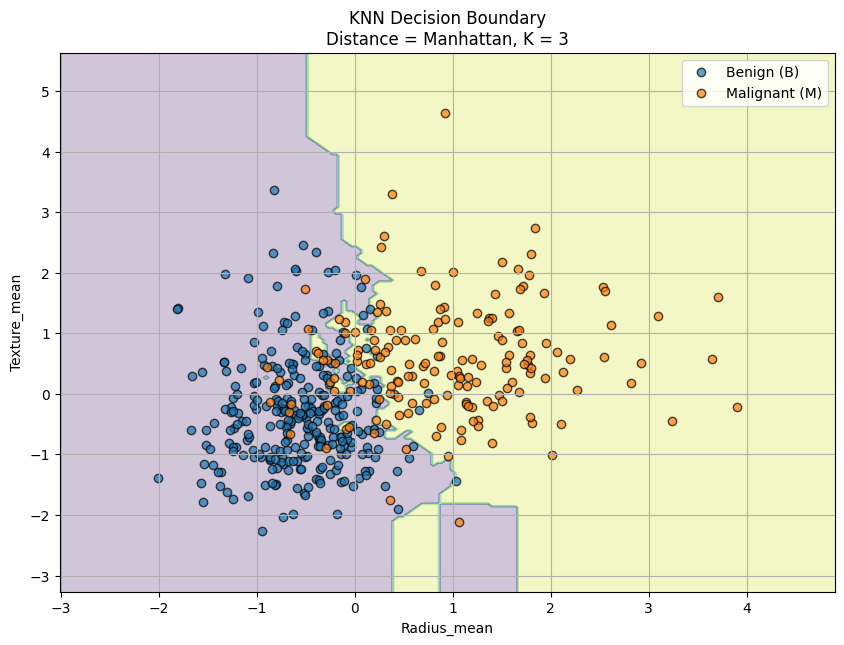

In [94]:
# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

# Benign = 0
plt.scatter(
    X_train_2D[y_train == 0, 0],
    X_train_2D[y_train == 0, 1],
    label="Benign (B)",
    edgecolors="black",
    alpha=0.7
)

# Malignant = 1
plt.scatter(
    X_train_2D[y_train == 1, 0],
    X_train_2D[y_train == 1, 1],
    label="Malignant (M)",
    edgecolors="black",
    alpha=0.7
)

plt.xlabel("Radius_mean")
plt.ylabel("Texture_mean")

plt.title(
    "KNN Decision Boundary\n"
    + "Distance = " + best_method
    + ", K = " + str(best_k)
)

plt.legend()
plt.grid()
plt.show()
